# Implementação de MLP ---> Introdução a DeepLearning

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

In [4]:
# Carregando a íris
iris = load_iris()
X = iris.data[:, :2]  # Usando apenas as duas primeiras características para melhorar a visualização
y = iris.target

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronizando
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Convertendo para tensores do PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [5]:
# Classe da MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim): # Imput_dim seria a quantidade de features, hidden_layers seria a quantidade de neuronios por camada oculta e output_dim seria quantas classes de saída tem
       
       # Classe pai para o pytorch
        super(MLP, self).__init__() 
        
        layers = []
        last_dim = input_dim #Inicialmente com o tamanho de entrada
        
        # Esse loop percore a lista de hidden layers
        for neurons in hidden_layers:
            # adiciona uma camada linear (função afim)
            layers.append(nn.Linear(last_dim, neurons))
            # Adiciona RELU como função de ativação
            layers.append(nn.ReLU()) # Função de ativação
            # Atualiza o last_dim
            last_dim = neurons
            
        # Camada de saída sem função de ativação, pois usaremos CrossEntropyLoss que já inclui softmax
        layers.append(nn.Linear(last_dim, output_dim))
        
        # Empacotamento, nn.Sequential garante o fluxo correto dos dados pelas camadas seguintes
        self.network = nn.Sequential(*layers)

    def forward(self, x): # Define o foward pass
        return self.network(x)

In [6]:
#Função de Treinamento e avaliação ---> Levando em conta o Dataset da iris
def treinar_e_avaliar_mlp(hidden_layers, taxa_aprendizado, taxa_momento, otimizador_nome, epocas=200):
    # Definindo as dimensões
    input_dim = X_train.shape[1] # 2 features
    output_dim = len(np.unique(y)) # 3 classes 
    
    # Instanciando o modelo
    modelo = MLP(input_dim, hidden_layers, output_dim)
    
    # Função de perda para classificação multiclasse
    criterion = nn.CrossEntropyLoss()
    
    # Escolha do Otimizador
    if otimizador_nome.lower() == 'sgd':
        optimizer = optim.SGD(modelo.parameters(), lr=taxa_aprendizado, momentum=taxa_momento)
    elif otimizador_nome.lower() == 'adam':
        # Adam não usa o parâmetro 'momentum' com esse nome, usa betas, então passamos só a LR
        optimizer = optim.Adam(modelo.parameters(), lr=taxa_aprendizado)
    else:
        raise ValueError("Otimizador não suportado. Escolha 'sgd' ou 'adam'.")

    # Histórico para os gráficos
    historico_loss = []
    historico_acc = []

    # Loop de Treinamento
    for epoca in range(epocas):
        modelo.train()
        
        # Forward pass
        outputs = modelo(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        # Backward pass e otimização
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Avaliando no conjunto de teste a cada época
        modelo.eval()
        with torch.no_grad():
            test_outputs = modelo(X_test_tensor)
            _, previstos = torch.max(test_outputs, 1)
            acuracia = (previstos == y_test_tensor).sum().item() / y_test_tensor.size(0)
            
        historico_loss.append(loss.item())
        historico_acc.append(acuracia)

    print(f"Treinamento concluído! Acurácia final no teste: {historico_acc[-1]*100:.2f}%")
    return modelo, historico_loss, historico_acc

Treinamento concluído! Acurácia final no teste: 93.33%


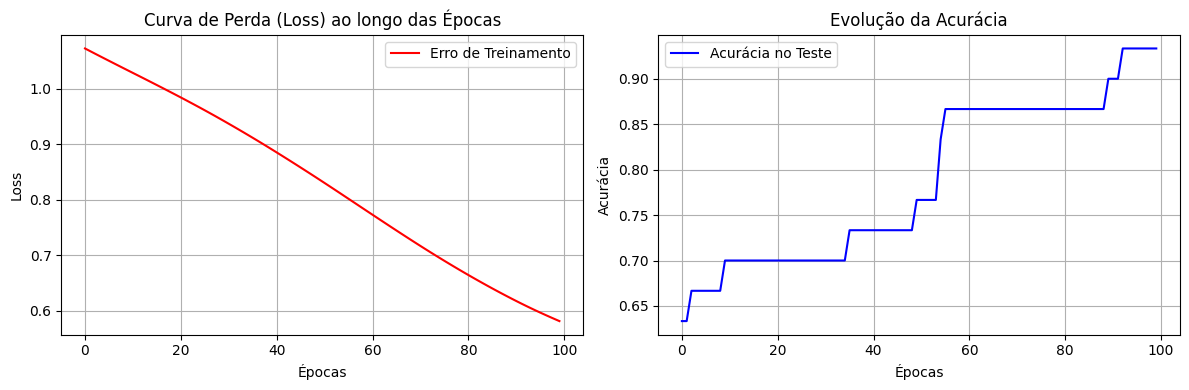

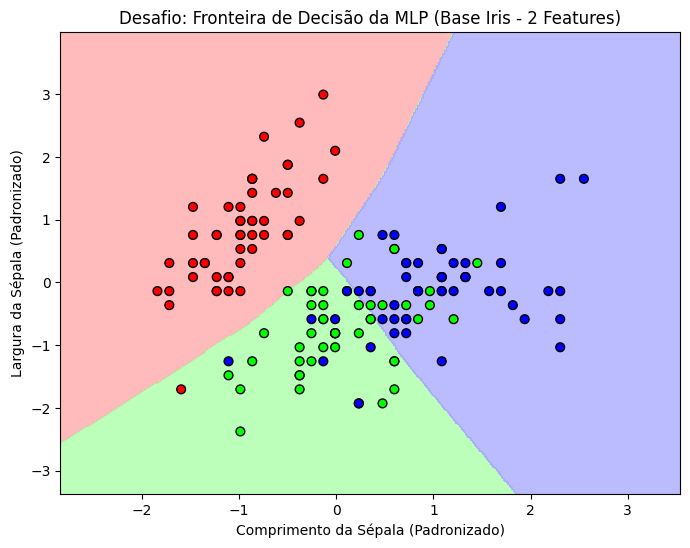

In [22]:
# Execução e Plotagem

# Entrada dos parametros vvv
CAMADAS_OCULTAS = [16, 16] # Duas camadas com 16 neurônios cada
TAXA_APRENDIZADO = 0.001
TAXA_MOMENTO = 0.9
OTIMIZADOR = 'adam' # Pode mudar para 'adam' ou 'sgd'
EPOCAS = 100

#Treinamento
modelo_treinado, perdas, acuracias = treinar_e_avaliar_mlp(
    hidden_layers=CAMADAS_OCULTAS, 
    taxa_aprendizado=TAXA_APRENDIZADO, 
    taxa_momento=TAXA_MOMENTO, 
    otimizador_nome=OTIMIZADOR,
    epocas=EPOCAS
)

#Gráficos e Análise
plt.figure(figsize=(12, 4))

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 1)
plt.plot(perdas, color='red', label='Erro de Treinamento')
plt.title('Curva de Perda (Loss) ao longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(acuracias, color='blue', label='Acurácia no Teste')
plt.title('Evolução da Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Fronteira de Decisão
def plotar_fronteira_decisao(modelo, X, y):
    # Definindo os limites do gráfico baseados nos dados padronizados
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Criando um grid de pontos
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Prevendo a classe para cada ponto do grid
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    modelo.eval()
    with torch.no_grad():
        Z = modelo(grid_tensor)
        _, Z = torch.max(Z, 1)
    
    Z = Z.numpy().reshape(xx.shape)
    
    # Plotando
    plt.figure(figsize=(8, 6))
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
    
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=40)
    
    plt.title('Desafio: Fronteira de Decisão da MLP (Base Iris - 2 Features)')
    plt.xlabel('Comprimento da Sépala (Padronizado)')
    plt.ylabel('Largura da Sépala (Padronizado)')
    plt.show()

# Juntando treino e teste para plotar a fronteira com todos os dados
X_total = np.vstack((X_train, X_test))
y_total = np.concatenate((y_train, y_test))

plotar_fronteira_decisao(modelo_treinado, X_total, y_total)